**IMPORT LIBRARIES**

In [ ]:
# Import Libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, confusion_matrix

**UPLOAD DATASET**

In [55]:
from google.colab import files
uploaded = files.upload()

Saving titanic_dataset.csv to titanic_dataset (1).csv


**LOAD DATASET**

In [ ]:

df = pd.read_csv('titanic_dataset.csv')

# Display first 5 rows
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


**MAKE PassengerId AS INDEX Column**

In [ ]:


df.set_index('PassengerId', inplace=True)

df.head()

,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
PassengerId,,,,,,,,,,,
1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


**BASIC DETAILS OF DATASET**

In [ ]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
Index: 891 entries, 1 to 891
Data columns (total 11 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Survived  891 non-null    int64  
 1   Pclass    891 non-null    int64  
 2   Name      891 non-null    object 
 3   Sex       891 non-null    object 
 4   Age       714 non-null    float64
 5   SibSp     891 non-null    int64  
 6   Parch     891 non-null    int64  
 7   Ticket    891 non-null    object 
 8   Fare      891 non-null    float64
 9   Cabin     204 non-null    object 
 10  Embarked  889 non-null    object 
dtypes: float64(2), int64(4), object(5)
memory usage: 83.5+ KB
None


In [ ]:
# Statistical Summary

df.describe()


,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


**Shape of Dataset**

In [ ]:
print("Shape of Dataset:", df.shape)

Shape of Dataset: (891, 11)


**Missing Values**

In [ ]:
df.isnull().sum()

,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0
Cabin,687


**VISUALIZATION OF MISSING VALUES**

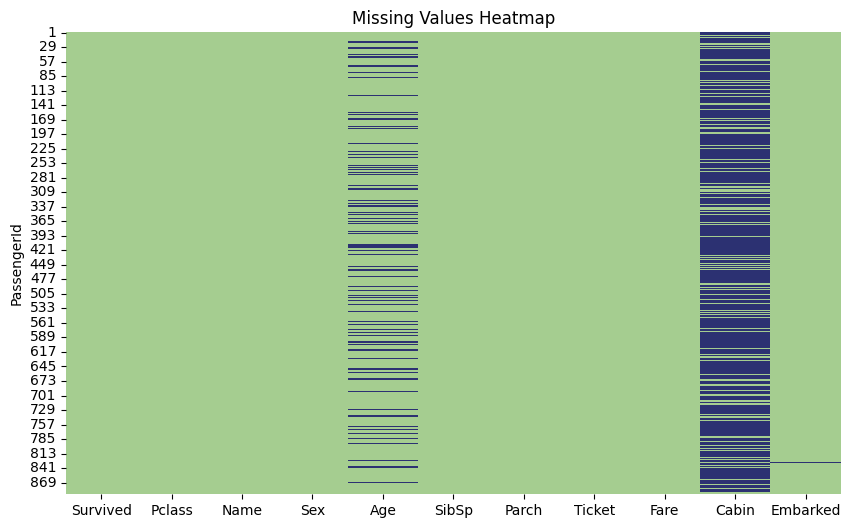

In [ ]:
# Heatmap for Missing Values

plt.figure(figsize=(10,6))

sns.heatmap(df.isnull(), cbar=False, cmap='crest')

plt.title("Missing Values Heatmap")

plt.show()

**HANDLE MISSING VALUES**

   * *Fill Numerical Columns*








In [ ]:
# Fill Age with Median
df['Age'] = df['Age'].fillna(df['Age'].median())

# Fill Fare with Median
df['Fare'] = df['Fare'].fillna(df['Fare'].median())

* *Fill Categorical Columns*



In [ ]:
# Fill Embarked with Mode
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])

# Fill Cabin with 'Unknown'
df['Cabin'] = df['Cabin'].fillna('Unknown')

**Verify Missing Values Again**

In [ ]:

df.isnull().sum()

,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,0
SibSp,0
Parch,0
Ticket,0
Fare,0
Cabin,0


**VISUALIZATION AFTER HANDLING MISSING VALUES**

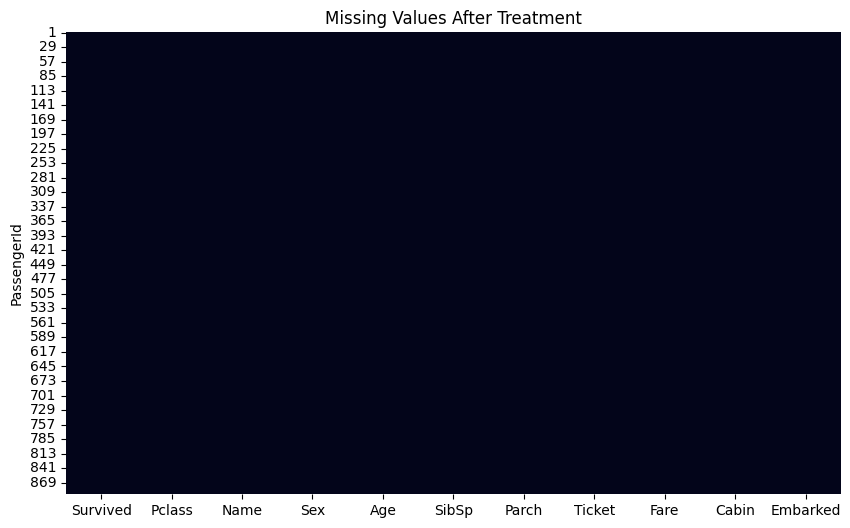

In [ ]:

plt.figure(figsize=(10,6))

sns.heatmap(df.isnull(), cbar=False, cmap='rocket')

plt.title("Missing Values After Treatment")

plt.show()

**ENCODE CATEGORICAL VARIABLES**

In [ ]:
# Label Encoding

le = LabelEncoder()

df['Sex'] = le.fit_transform(df['Sex'])

df['Embarked'] = le.fit_transform(df['Embarked'])

df['Cabin'] = le.fit_transform(df['Cabin'])

df['Name'] = le.fit_transform(df['Name'])

df['Ticket'] = le.fit_transform(df['Ticket'])

**OUTLIER DETECTION**
  
  1. Age
  2. Fare
  3. SibSp
  4. Parch
  5. Pclass  

**BOXPLOTS BEFORE OUTLIER HANDLING**

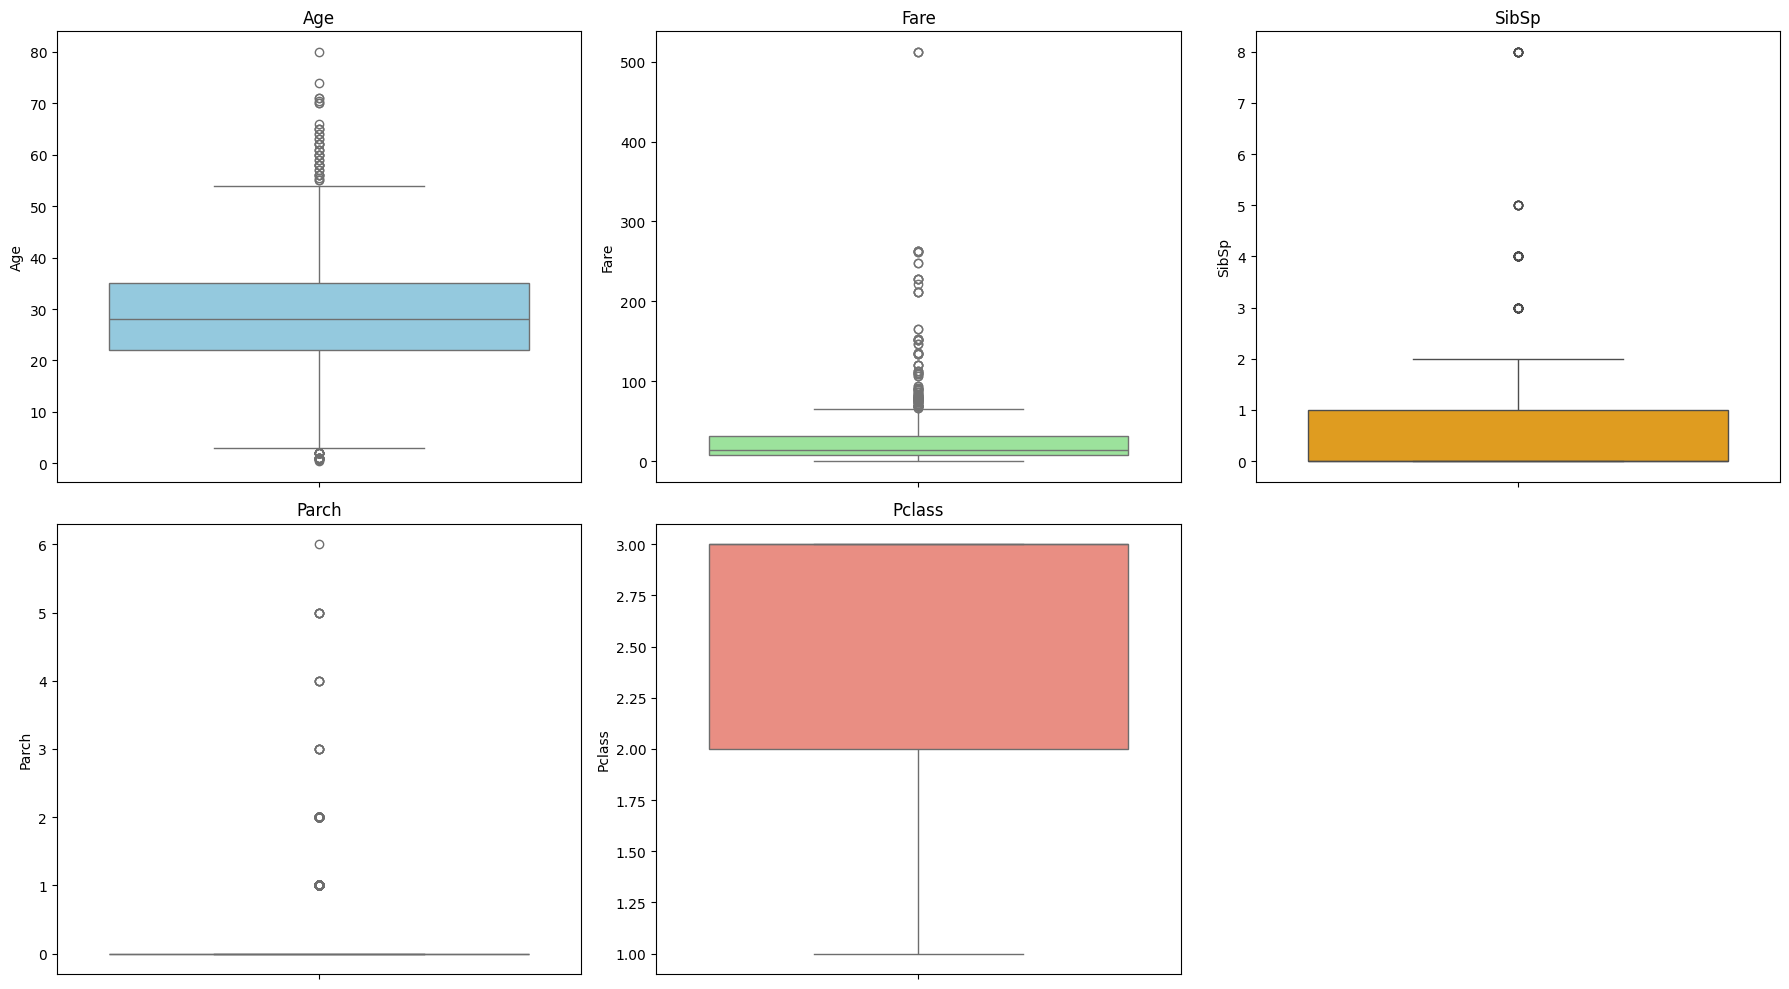

In [ ]:

plt.figure(figsize=(18,10))

# 1.Age
plt.subplot(2,3,1)
sns.boxplot(y=df['Age'], color='skyblue')
plt.title("Age")

# 2.Fare
plt.subplot(2,3,2)
sns.boxplot(y=df['Fare'], color='lightgreen')
plt.title("Fare")

# 3.SibSp
plt.subplot(2,3,3)
sns.boxplot(y=df['SibSp'], color='orange')
plt.title("SibSp")

# 4.Parch
plt.subplot(2,3,4)
sns.boxplot(y=df['Parch'], color='violet')
plt.title("Parch")

# 5.Pclass
plt.subplot(2,3,5)
sns.boxplot(y=df['Pclass'], color='salmon')
plt.title("Pclass")

plt.tight_layout()

plt.show()

**HANDLE OUTLIERS USING IQR METHOD**
 * Function for Outlier Handling


In [ ]:

def handle_outliers(column):

    Q1 = column.quantile(0.25)
    Q3 = column.quantile(0.75)

    IQR = Q3 - Q1

    lower_limit = Q1 - 1.5 * IQR
    upper_limit = Q3 + 1.5 * IQR

    column = np.where(column > upper_limit, upper_limit, column)
    column = np.where(column < lower_limit, lower_limit, column)

    return column

* Apply Outlier Handling







In [ ]:

df['Age'] = handle_outliers(df['Age'])

df['Fare'] = handle_outliers(df['Fare'])

df['SibSp'] = handle_outliers(df['SibSp'])

df['Parch'] = handle_outliers(df['Parch'])

df['Pclass'] = handle_outliers(df['Pclass'])

**BOXPLOTS AFTER OUTLIER HANDLING**

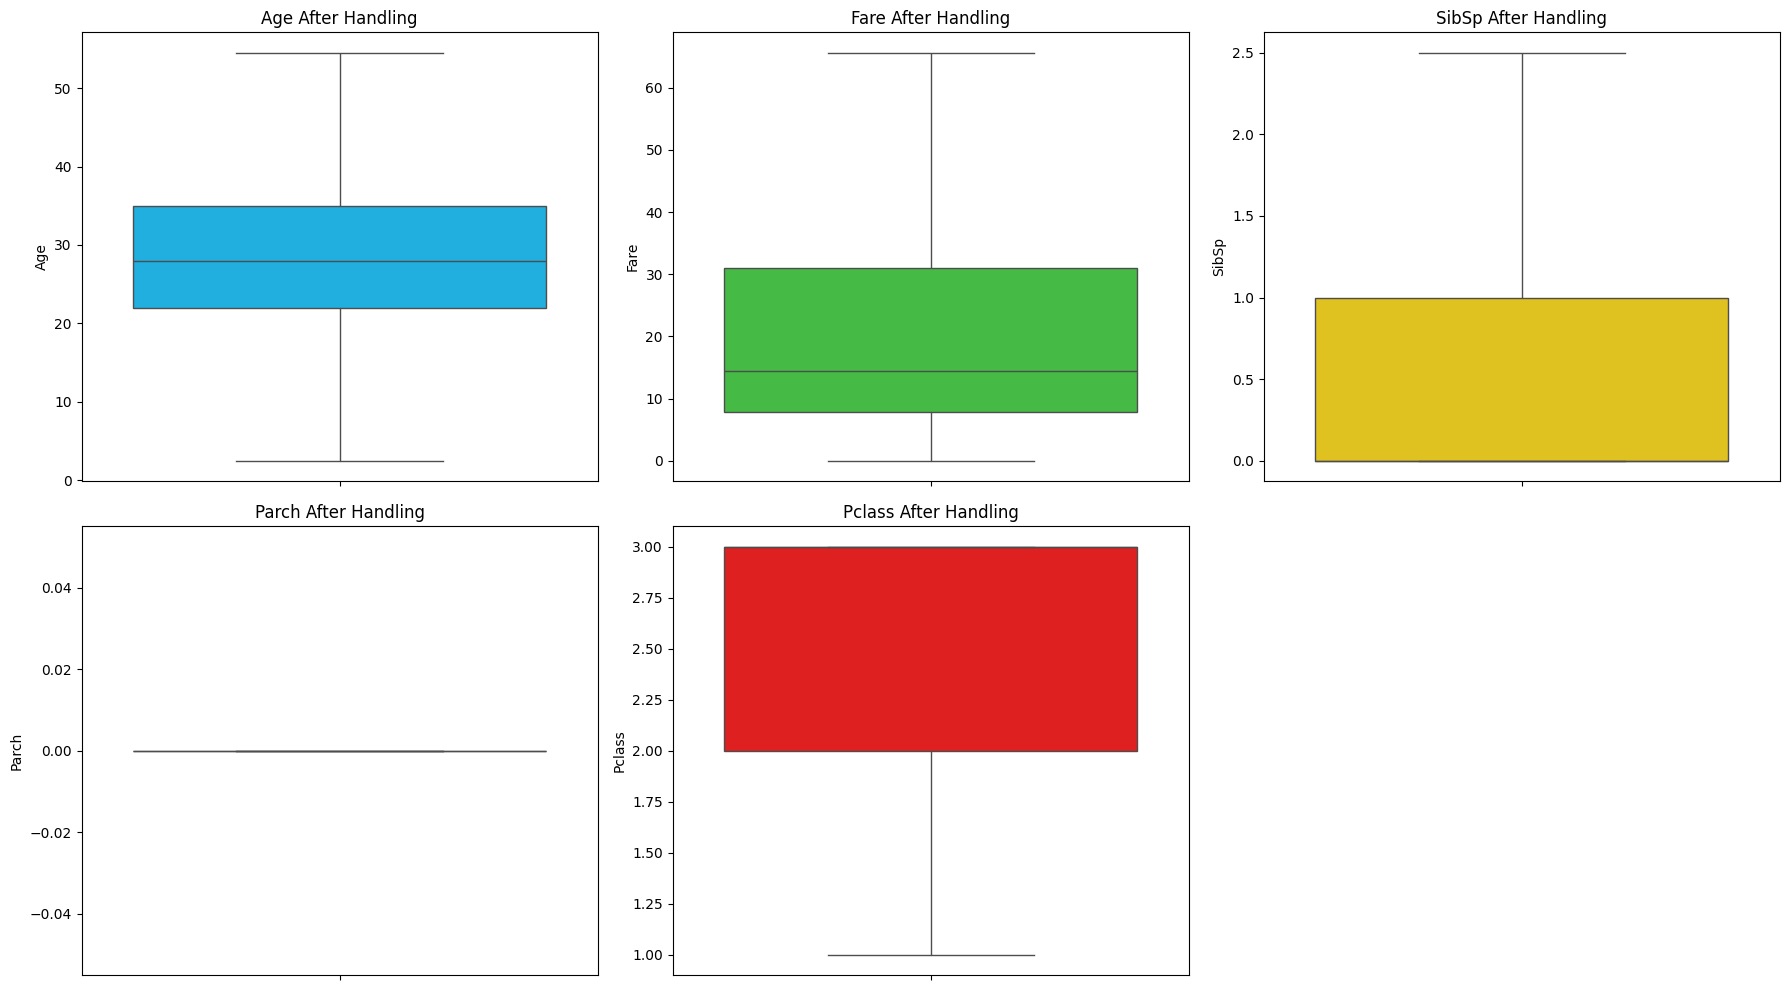

In [ ]:
plt.figure(figsize=(18,10))

# 1.Age
plt.subplot(2,3,1)
sns.boxplot(y=df['Age'], color='deepskyblue')
plt.title("Age After Handling")

# 2.Fare
plt.subplot(2,3,2)
sns.boxplot(y=df['Fare'], color='limegreen')
plt.title("Fare After Handling")

# 3.SibSp
plt.subplot(2,3,3)
sns.boxplot(y=df['SibSp'], color='gold')
plt.title("SibSp After Handling")


# 4.Parch
plt.subplot(2,3,4)
sns.boxplot(y=df['Parch'], color='yellow')
plt.title("Parch After Handling")

# 5.Pclass
plt.subplot(2,3,5)
sns.boxplot(y=df['Pclass'], color='red')
plt.title("Pclass After Handling")

plt.tight_layout()

plt.show()

**SURVIVAL COUNT VISUALIZATION**

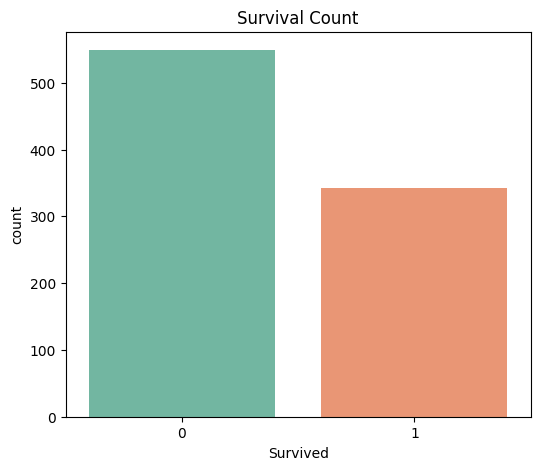

In [ ]:

plt.figure(figsize=(6,5))

sns.countplot(
    x='Survived',
    hue='Survived',
    data=df,
    palette='Set2',
    legend=False
)

plt.title("Survival Count")

plt.show()

**GENDER VS SURVIVAL**

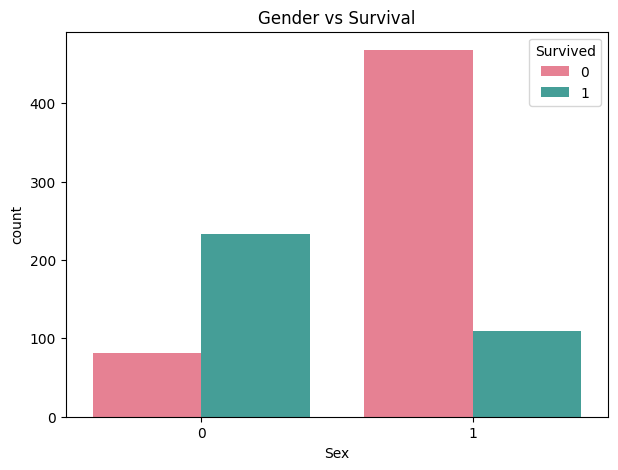

In [ ]:

plt.figure(figsize=(7,5))

sns.countplot(x='Sex', hue='Survived', data=df, palette='husl')

plt.title("Gender vs Survival")

plt.show()

**PASSENGER CLASS VS SURVIVAL**

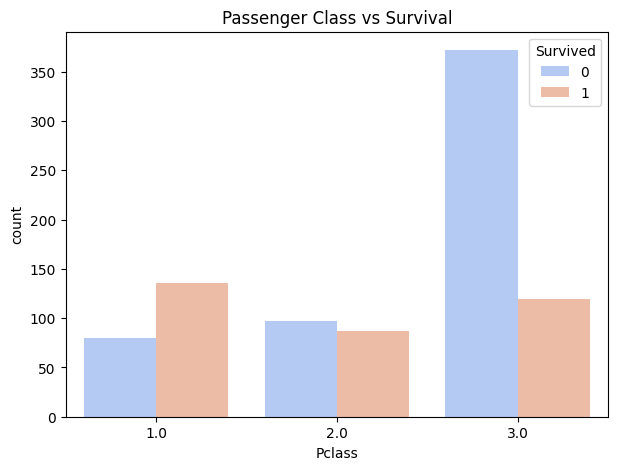

In [ ]:

plt.figure(figsize=(7,5))

sns.countplot(x='Pclass', hue='Survived', data=df, palette='coolwarm')

plt.title("Passenger Class vs Survival")

plt.show()

**AGE DISTRIBUTION**

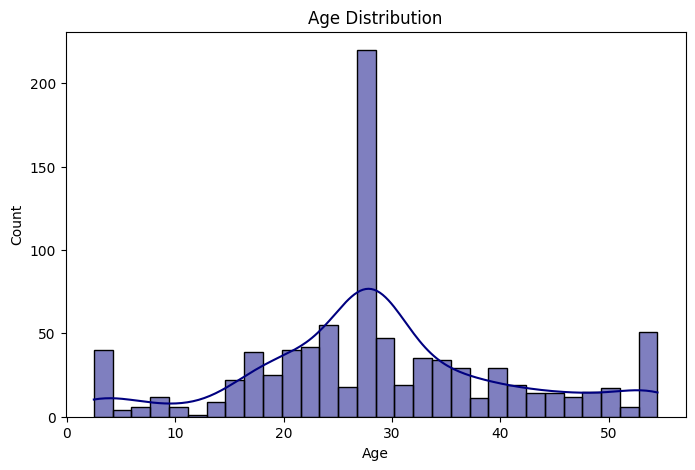

In [ ]:

plt.figure(figsize=(8,5))

sns.histplot(df['Age'], bins=30, kde=True, color='navy')

plt.title("Age Distribution")

plt.show()

**CORRELATION HEATMAP**

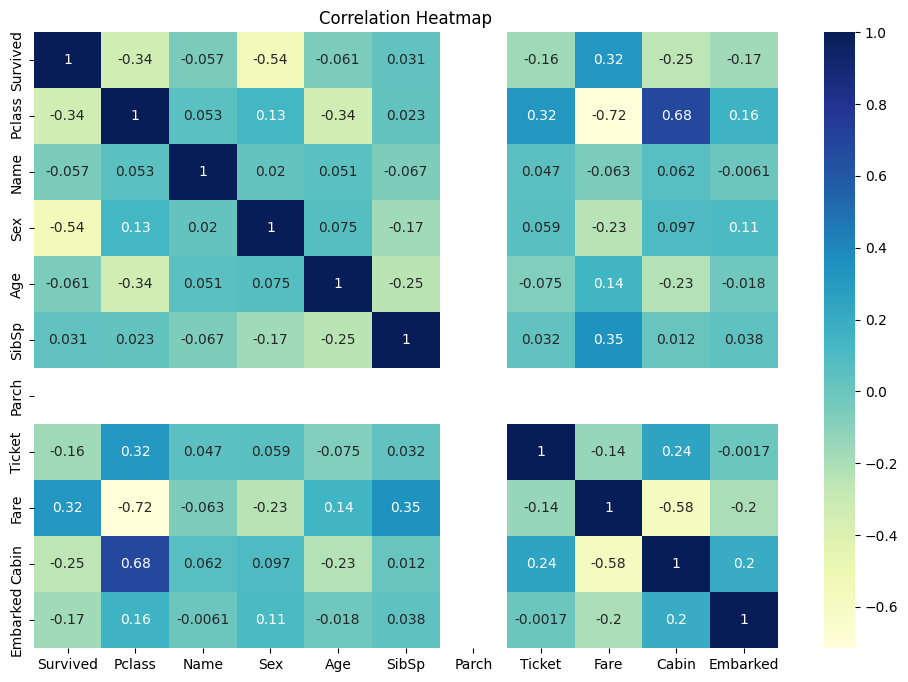

In [ ]:
# Correlation Heatmap

plt.figure(figsize=(12,8))

sns.heatmap(df.corr(), annot=True, cmap='YlGnBu')

plt.title("Correlation Heatmap")

plt.show()

**DEFINE FEATURES AND TARGET**

In [ ]:

X = df.drop('Survived', axis=1)

y = df['Survived']

**TRAIN TEST SPLIT**

In [ ]:

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

**LOGISTIC REGRESSION**

In [ ]:

lr = LogisticRegression(max_iter=1000)

lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)

lr_accuracy = accuracy_score(y_test, y_pred_lr)

print("Logistic Regression Accuracy:", lr_accuracy)

Logistic Regression Accuracy: 0.8212290502793296


**KNN CLASSIFIER**

In [ ]:

knn = KNeighborsClassifier()

knn.fit(X_train, y_train)

y_pred_knn = knn.predict(X_test)

knn_accuracy = accuracy_score(y_test, y_pred_knn)

print("KNN Accuracy:", knn_accuracy)

KNN Accuracy: 0.6815642458100558


**DECISION TREE**

In [ ]:

dt = DecisionTreeClassifier(random_state=42)

dt.fit(X_train, y_train)

y_pred_dt = dt.predict(X_test)

dt_accuracy = accuracy_score(y_test, y_pred_dt)

print("Decision Tree Accuracy:", dt_accuracy)

Decision Tree Accuracy: 0.7877094972067039


**RANDOM FOREST**

In [ ]:

rf = RandomForestClassifier(random_state=42)

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

rf_accuracy = accuracy_score(y_test, y_pred_rf)

print("Random Forest Accuracy:", rf_accuracy)

Random Forest Accuracy: 0.8156424581005587


**SVM**

In [ ]:

svm = SVC()

svm.fit(X_train, y_train)

y_pred_svm = svm.predict(X_test)

svm_accuracy = accuracy_score(y_test, y_pred_svm)

print("SVM Accuracy:", svm_accuracy)

SVM Accuracy: 0.6424581005586593


**NAIVE BAYES**

In [ ]:

nb = GaussianNB()

nb.fit(X_train, y_train)

y_pred_nb = nb.predict(X_test)

nb_accuracy = accuracy_score(y_test, y_pred_nb)

print("Naive Bayes Accuracy:", nb_accuracy)

Naive Bayes Accuracy: 0.7877094972067039


**MODEL COMPARISON TABLE**

In [ ]:

models = pd.DataFrame({
    'Model': [
        'Logistic Regression',
        'KNN',
        'Decision Tree',
        'Random Forest',
        'SVM',
        'Naive Bayes'
    ],

    'Accuracy': [
        lr_accuracy,
        knn_accuracy,
        dt_accuracy,
        rf_accuracy,
        svm_accuracy,
        nb_accuracy
    ]
})

models

,Model,Accuracy
0,Logistic Regression,0.821229
1,KNN,0.681564
2,Decision Tree,0.787709
3,Random Forest,0.815642
4,SVM,0.642458
5,Naive Bayes,0.787709


**MODEL ACCURACY VISUALIZATION**

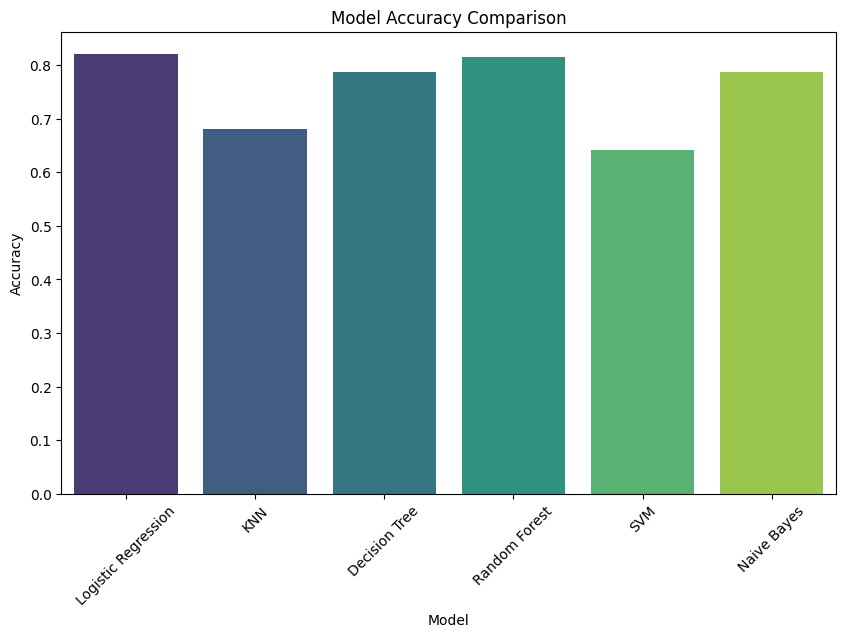

In [ ]:
# Accuracy Comparison Graph

plt.figure(figsize=(10,6))

sns.barplot(
    x='Model',
    y='Accuracy',
    hue='Model',
    data=models,
    palette='viridis',
    legend=False
)

plt.xticks(rotation=45)

plt.title("Model Accuracy Comparison")

plt.show()

**BEST MODEL**

In [ ]:

best_model = models.loc[models['Accuracy'].idxmax()]

print(best_model)

Model       Logistic Regression
Accuracy               0.821229
Name: 0, dtype: object


**CONFUSION MATRIX**

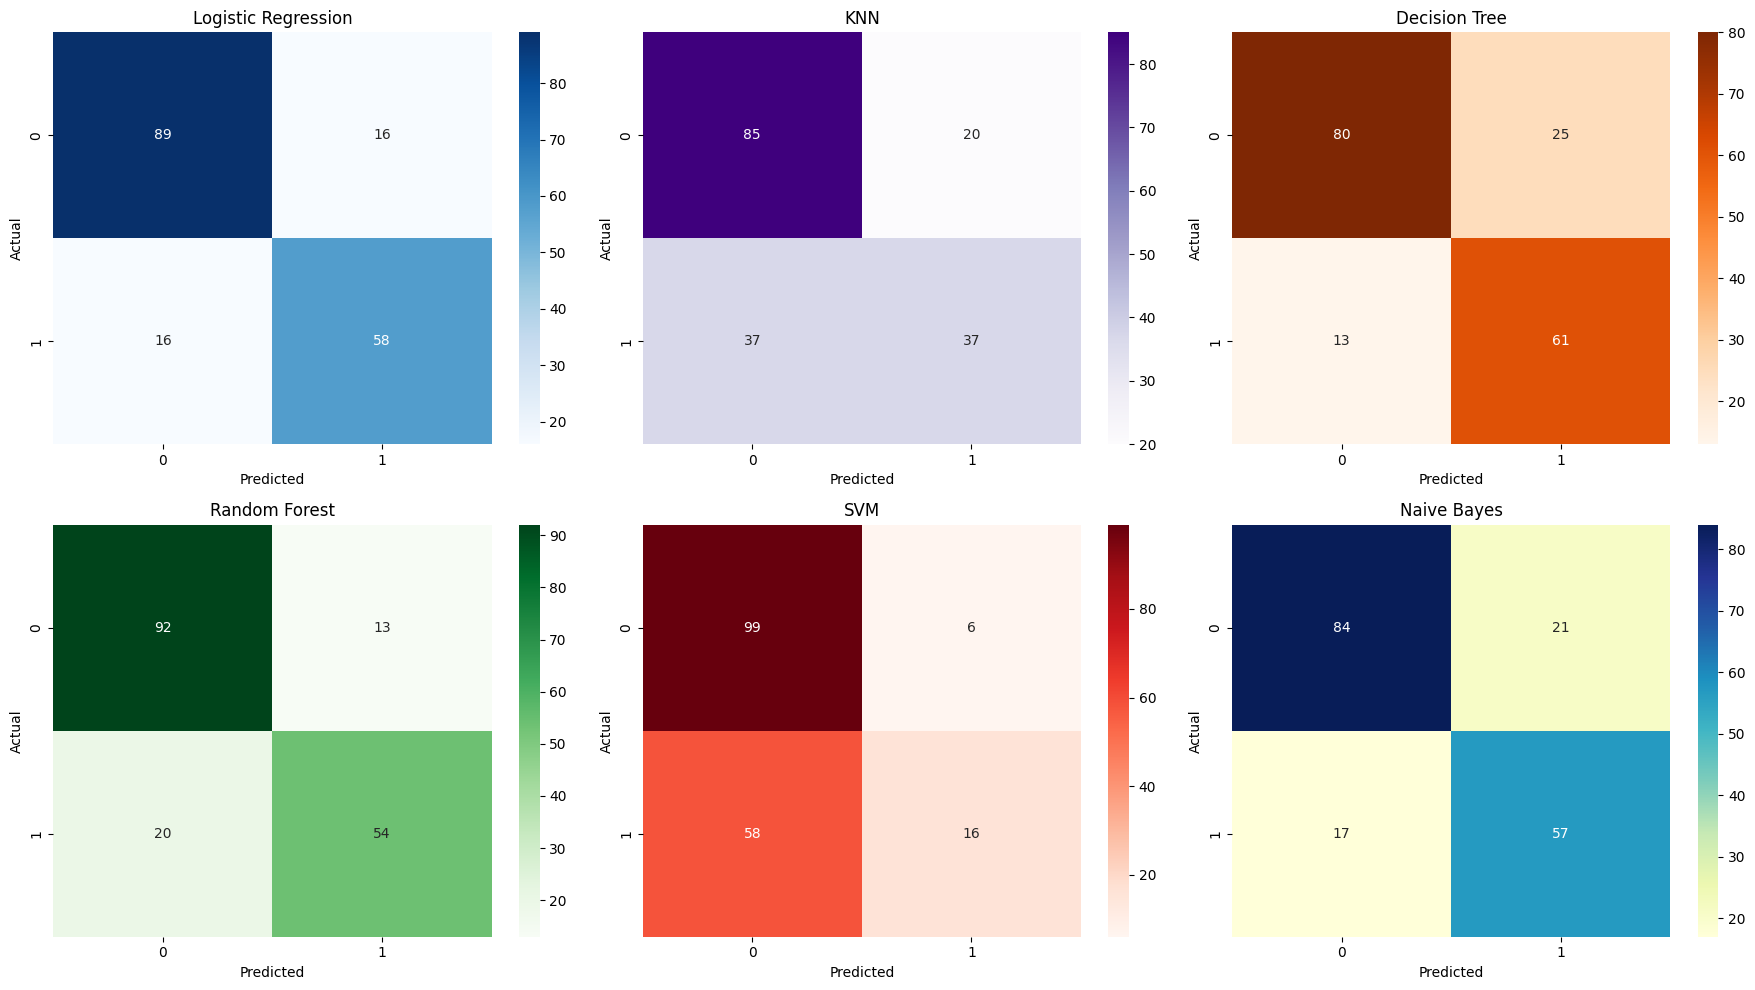

In [ ]:
# Confusion Matrices for All Models

models_predictions = {
    'Logistic Regression': y_pred_lr,
    'KNN': y_pred_knn,
    'Decision Tree': y_pred_dt,
    'Random Forest': y_pred_rf,
    'SVM': y_pred_svm,
    'Naive Bayes': y_pred_nb
}

# Different colormaps
colors = [
    'Blues',
    'Purples',
    'Oranges',
    'Greens',
    'Reds',
    'YlGnBu'
]

plt.figure(figsize=(18,10))

for i, ((name, pred), color) in enumerate(zip(models_predictions.items(), colors), 1):

    plt.subplot(2,3,i)

    cm = confusion_matrix(y_test, pred)

    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap=color
    )

    plt.title(name)

    plt.xlabel("Predicted")

    plt.ylabel("Actual")

plt.tight_layout()

plt.show()

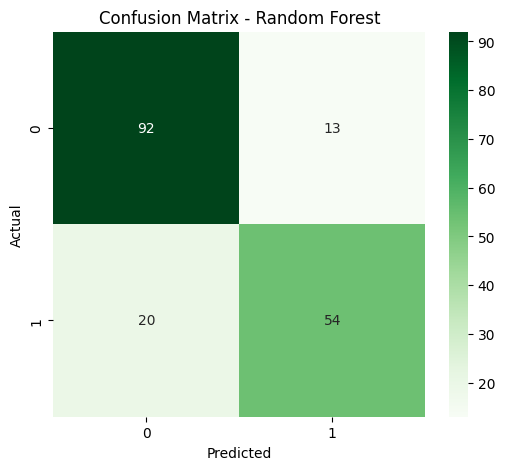

In [ ]:
# Confusion Matrix for Random Forest only because it is found as the best among all models.

cm = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(6,5))

sns.heatmap(cm, annot=True, fmt='d', cmap='Greens')

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.title("Confusion Matrix - Random Forest")

plt.show()

**CONCLUSION**

- Successfully loaded and analyzed the Titanic dataset.
- PassengerId was set as the index column.
- All missing values were handled properly.
- Outliers in Age, Fare, SibSp, Parch and Pclass were detected and treated.
- Multiple visualizations were created for better understanding.
- Different classification models were implemented and evaluated the best model.
- Random Forest achieved the best performance among all models.





    

